ARTI308 - Machine Learning

# Customer Segmentation with K-Means

In this lab, we will work with an unsupervised learning problem. We will use customer data and apply K-Means clustering to discover groups of customers based on their behavior.The main goal of this lab is not to predict a label. Instead, the goal is to discover hidden patterns in the data.

## Introduction

In supervised learning, the dataset contains a target label. While in unsupervised learning, the dataset does not contain a target label.
Clustering is one of the most common unsupervised learning techniques. It groups similar data points together based on their features.

## Import Libraries

We start by importing the libraries we usually use for data analysis, visualization, preprocessing, and clustering.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Get the Data

Read the `mall_customers.csv` file.

This dataset contains customer information, including gender, age, annual income, and spending score.

For this lab, we will focus mainly on:

* Annual Income (k$)
* Spending Score (1-100)

These two features are useful for customer segmentation because they describe customer purchasing behavior in a simple visual way.

In [2]:
customers = pd.read_csv('mall_customers.csv')

**Check the head of the data.**

In [3]:
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,48,31,23
1,2,Male,42,26,28
2,3,Male,49,24,37
3,4,Female,58,23,21
4,5,Female,41,15,19


**Check basic information about the dataset.**

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**Check summary statistics for the numerical columns.**

In [5]:
customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.00000,200.000000,200.000000
mean,100.500000,37.75000,55.590000,51.740000
std,57.879185,11.27979,27.617668,25.439107
min,1.000000,18.00000,15.000000,6.000000
25%,50.750000,29.00000,31.000000,27.750000
50%,100.500000,37.00000,54.000000,50.000000
75%,150.250000,46.00000,79.250000,75.250000
max,200.000000,66.00000,127.000000,100.000000


## Exploratory Data Analysis

Before applying clustering, we need to understand the data visually. First, let us look at the distribution of the numerical columns.

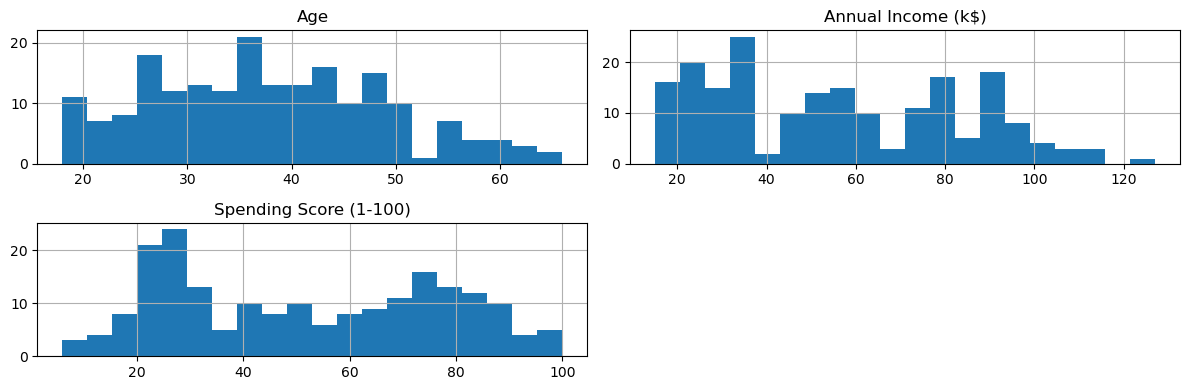

In [6]:
customers[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(figsize=(12,4), bins=20)
plt.tight_layout()

The histograms show how the numerical values are distributed. They help us notice whether the data is balanced, spread out, or concentrated around specific ranges.

## Visualize Income and Spending Score

Now we will create a scatter plot. Each point represents one customer. The x-axis shows annual income, and the y-axis shows spending score. At this stage, we are not using labels. We are only observing whether natural groups may exist.

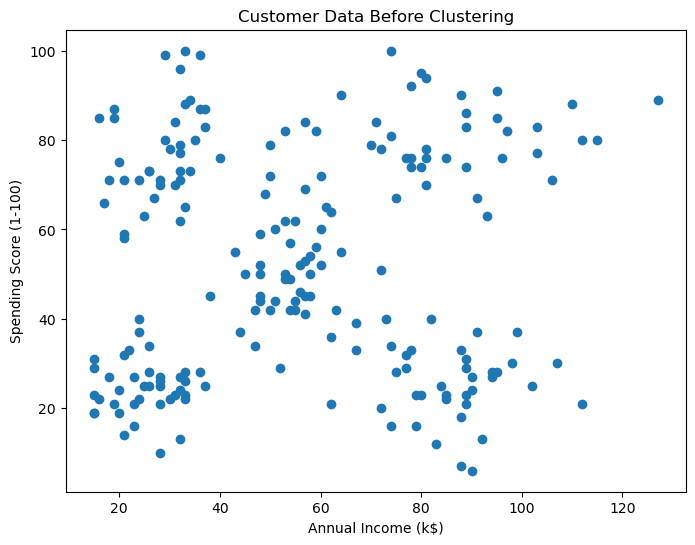

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(customers['Annual Income (k$)'], customers['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data Before Clustering')
plt.show()

The scatter plot shows customers based on income and spending score before clustering. We can visually notice possible groups, but the algorithm has not assigned any clusters yet.

## Select Features for Clustering

K-Means uses distance between points. Therefore, we will select the two numerical features that we want the algorithm to use. In this example, we will use annual income and spending score.

In [8]:
X = customers[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,31,23
1,26,28
2,24,37
3,23,21
4,15,19


The variable `X` now contains only the two features used for clustering. K-Means will group customers based on these two columns.

## Feature Scaling

K-Means is distance-based. If one feature has a much larger scale than another feature, it can dominate the clustering result.

To avoid this problem, we use standardization.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.89260638, -1.13259169],
       [-1.07410422, -0.93555068],
       [-1.14670336, -0.58087688],
       [-1.18300292, -1.21140809],
       [-1.47339947, -1.29022449]])

## K-Means with a First Choice of K

K-Means requires us to choose the number of clusters, K. We will start with `K = 5` because customer segmentation is often easier to interpret with a small number of business groups.

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

customers['Cluster'] = cluster_labels
customers.head()

c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,48,31,23,0
1,2,Male,42,26,28,0
2,3,Male,49,24,37,0
3,4,Female,58,23,21,0
4,5,Female,41,15,19,0


A new column called `Cluster` has been added. The numbers are not real class labels; they are cluster IDs assigned by K-Means.

## Cluster Centers

The cluster centers are called **centroids**. Since we used scaled data for training, the centroids are also in the scaled feature space. To interpret them in the original units, we convert them back using `inverse_transform`.

In [11]:
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centers_df

,Annual Income (k$),Spending Score (1-100)
0,25.076923,24.564103
1,85.789474,25.394737
2,31.909091,77.454545
3,87.942857,80.714286
4,54.500000,49.818182


## Visualize the Clusters

Now we will plot the customers again, but this time we will color each point based on its cluster. The black X markers represent the cluster centroids.

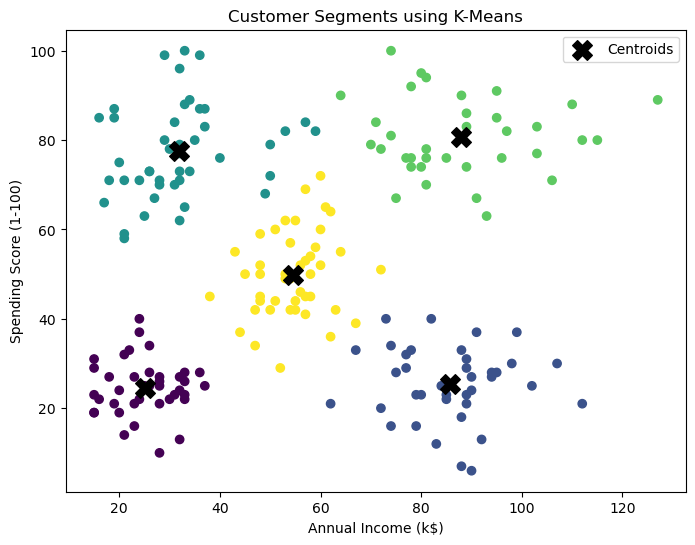

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    customers['Annual Income (k$)'],
    customers['Spending Score (1-100)'],
    c=customers['Cluster'],
    cmap='viridis'
)

plt.scatter(
    centers_df['Annual Income (k$)'],
    centers_df['Spending Score (1-100)'],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments using K-Means')
plt.legend()
plt.show()

The plot shows the customer segments found by K-Means. Points with the same color belong to the same cluster, and the black X markers show the cluster centers.

## Count Customers in Each Cluster

This helps us understand the size of each customer segment.

In [13]:
customers['Cluster'].value_counts().sort_index()

Cluster
0    39
1    38
2    44
3    35
4    44
Name: count, dtype: int64

## Choosing K Intuitively

Choosing the number of clusters (K) is one of the most important and challenging steps in K-Means. There is no single correct answer. Instead, we use multiple techniques to guide our decision.

In this section, we will combine:
- Visual intuition
- Elbow method
- Silhouette score

This helps us make a more reliable decision instead of depending on only one method.


### Visual Method

Before relying on metrics, always look at the data. Plot the data and try to visually estimate how many groups exist. This gives an initial intuition for possible values of K.

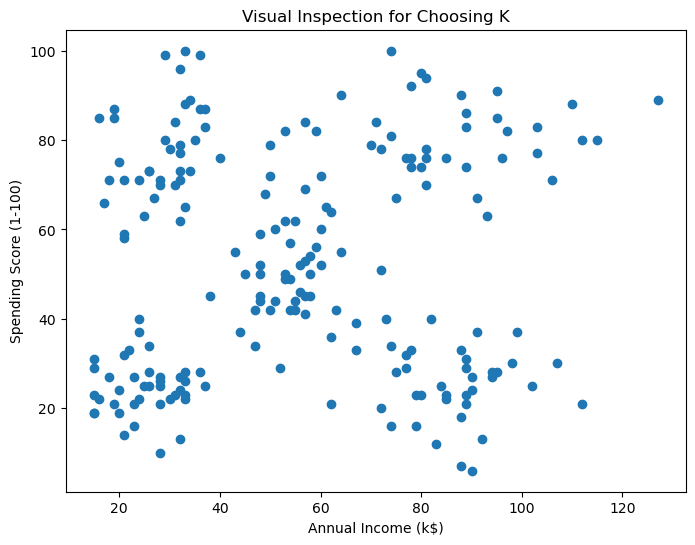

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(customers['Annual Income (k$)'], customers['Spending Score (1-100)'])
plt.title('Visual Inspection for Choosing K')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

From this plot, we try to visually identify how many groups might exist. You may notice around 4 to 6 possible clusters. This is only an initial guess and will be refined using other methods.


### Comparing Different K Values

Instead of choosing K directly, we try several values and compare the results.

We will:
1. Run K-Means for different values of K
2. Visualize the clusters
3. Compare how the clustering changes


c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

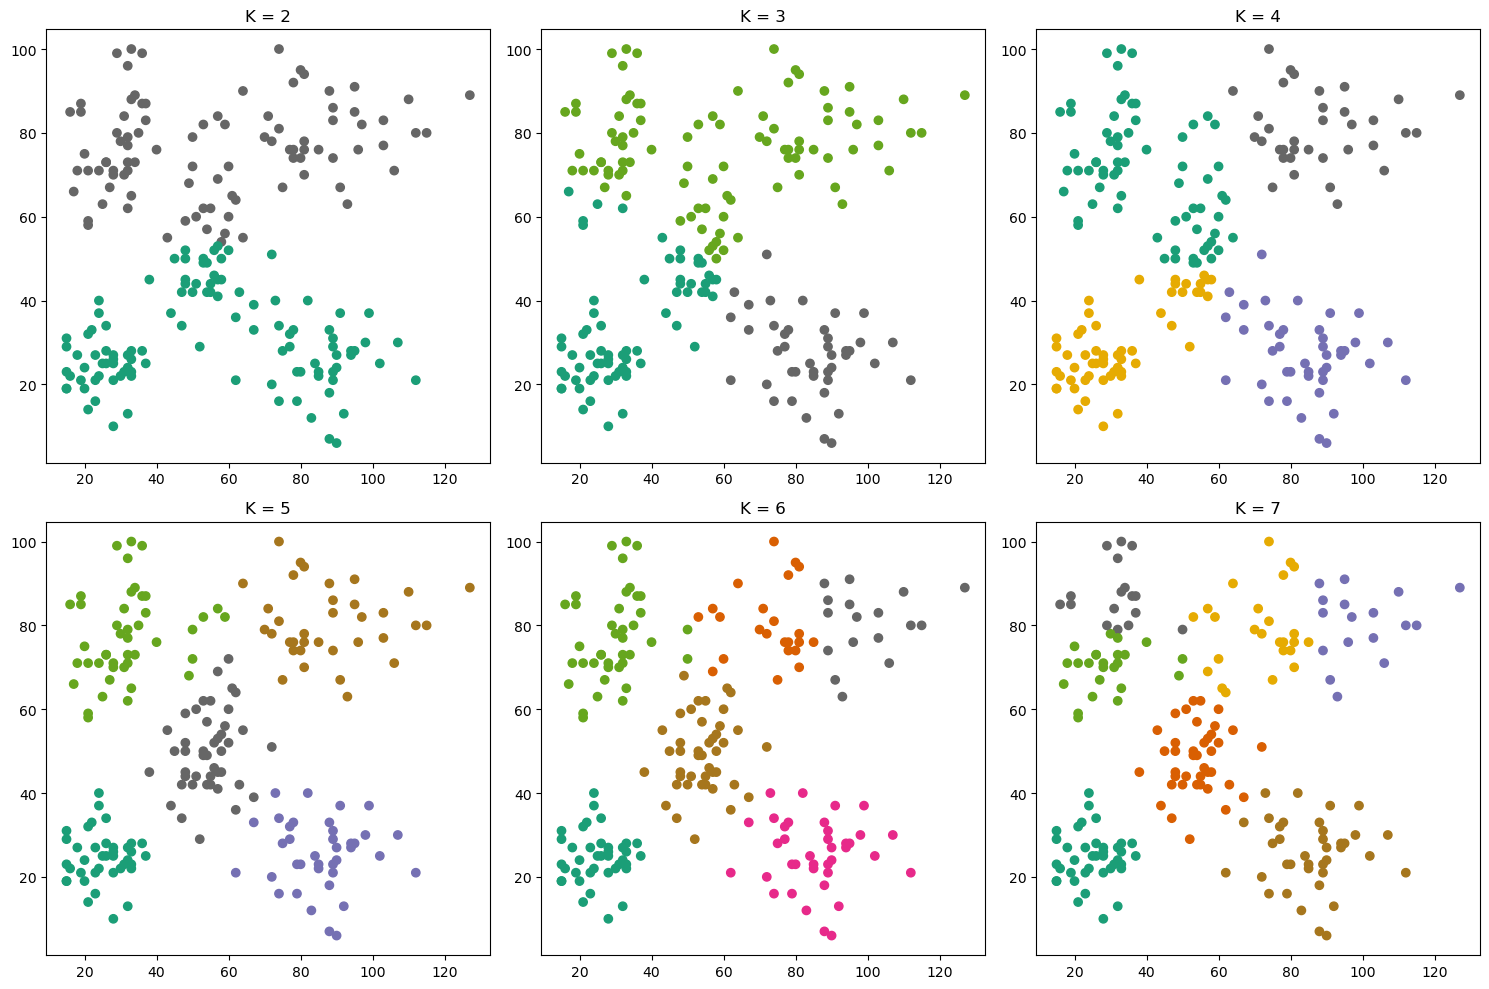

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

k_values = [2, 3, 4, 5, 6,7]

for i, k in enumerate(k_values):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    axes[i].scatter(
        customers['Annual Income (k$)'],
        customers['Spending Score (1-100)'],
        c=labels,
        cmap='Dark2' # you can change this
    )
    axes[i].set_title(f'K = {k}')

plt.tight_layout()
plt.show()

to change the colors of the plot, checkout this [link](https://matplotlib.org/stable/users/explain/colors/colormaps.html).

Each subplot shows clustering for a different value of K.

- When K is too small, clusters are too broad.
- When K is too large, clusters become fragmented.
- A good K gives clear and meaningful separation without overcomplicating the grouping.

This visual comparison helps confirm the results from the elbow and silhouette methods.


## Choosing K using the Elbow Method

The elbow method compares inertia for different values of K. Inertia measures how close points are to their assigned cluster centroids. As K increases, inertia usually decreases. However, after a certain point, the improvement becomes small. That point is called the elbow.

c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

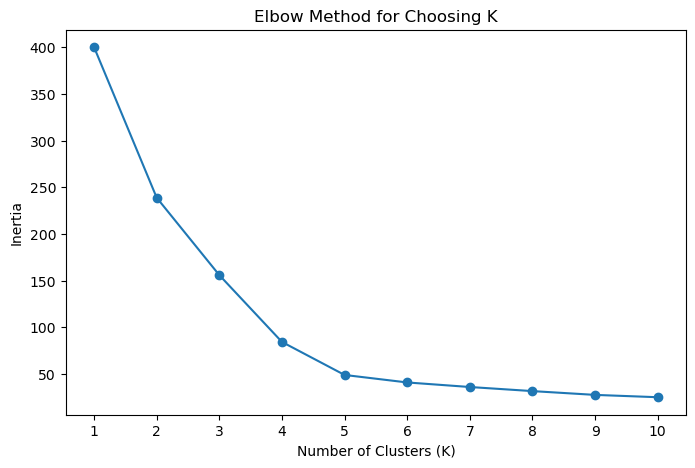

In [16]:
inertia_values = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing K')
plt.xticks(K_range)
plt.show()

The elbow curve shows how inertia changes as K increases. We look for the point where the decrease starts to slow down, because that point may suggest a good number of clusters.

## Choosing K using Silhouette Score

The silhouette score measures how well-separated the clusters are. A higher silhouette score usually indicates better clustering. The score ranges from -1 to 1:

* Close to 1 means good clustering
* Close to 0 means overlapping clusters
* Close to -1 means poor assignment

c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

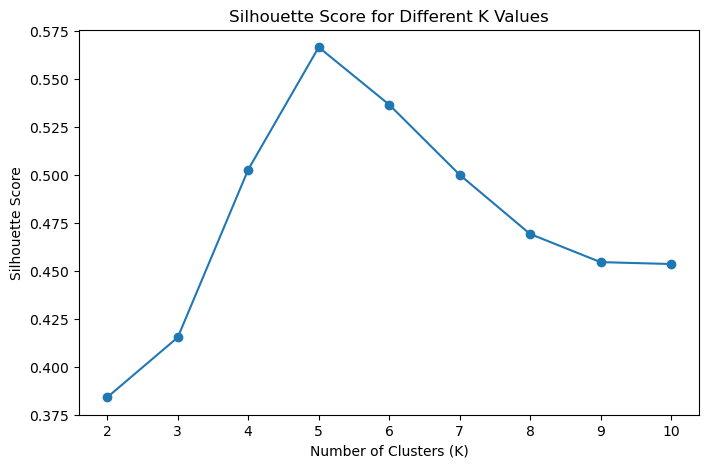

In [17]:
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(K_range)
plt.show()

The silhouette plot compares clustering quality for different K values. Higher values usually mean the clusters are more clearly separated.

**Display the silhouette scores in a table.**

In [18]:
score_table = pd.DataFrame({
    'K': list(range(2, 11)),
    'Silhouette Score': silhouette_scores
})

score_table

,K,Silhouette Score
0,2,0.384083
1,3,0.415302
2,4,0.502794
3,5,0.566563
4,6,0.536635
5,7,0.500085
6,8,0.469204
7,9,0.454520
8,10,0.453533


This table gives the exact silhouette score for each K value. It makes it easier to compare the values instead of relying only on the plot.

## Final Model

Based on the elbow method and silhouette score, we can choose a final value for K.

In this lab, we will use K = 5 because it gives clear and interpretable customer groups.

In [19]:
final_model = KMeans(n_clusters=5, random_state=42, n_init=10)
customers['Final Cluster'] = final_model.fit_predict(X_scaled)

final_centers = scaler.inverse_transform(final_model.cluster_centers_)
final_centers_df = pd.DataFrame(final_centers, columns=['Annual Income (k$)', 'Spending Score (1-100)'])

customers.head()

c:\Users\Koduro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Final Cluster
0,1,Male,48,31,23,0,0
1,2,Male,42,26,28,0,0
2,3,Male,49,24,37,0,0
3,4,Female,58,23,21,0,0
4,5,Female,41,15,19,0,0


## Final Visualization

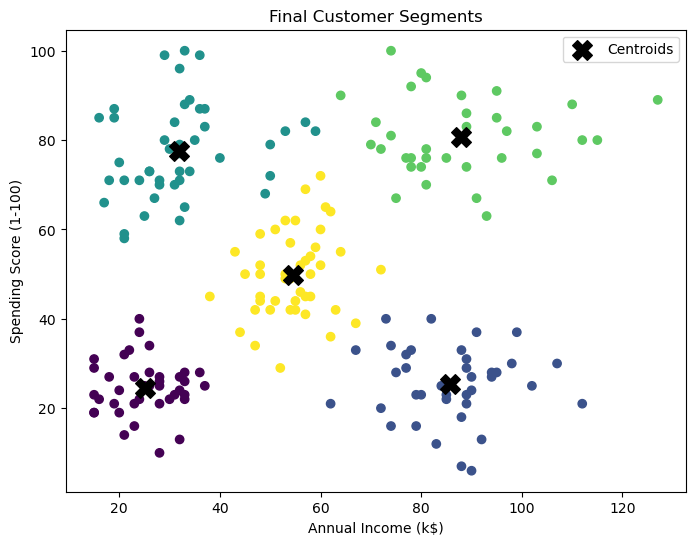

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    customers['Annual Income (k$)'],
    customers['Spending Score (1-100)'],
    c=customers['Final Cluster'],
    cmap='viridis'
)

plt.scatter(
    final_centers_df['Annual Income (k$)'],
    final_centers_df['Spending Score (1-100)'],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Final Customer Segments')
plt.legend()
plt.show()

This final plot shows the selected customer segments. It helps us visually check whether the chosen K gives clear and meaningful groups.

## Cluster Interpretation

Now we summarize each cluster using the original customer features. This step is important because clustering is not useful unless we can interpret the groups.

In [21]:
cluster_summary = customers.groupby('Final Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Final Cluster,,,
0,41.051282,25.076923,24.564103
1,45.789474,85.789474,25.394737
2,26.659091,31.909091,77.454545
3,33.714286,87.942857,80.714286
4,42.181818,54.500000,49.818182


## Interpretation Example

After looking at the cluster centers and summary table, we can describe the customer groups.

For example:

* Customers with high income and high spending score may be valuable loyal customers.
* Customers with high income and low spending score may need different marketing strategies.
* Customers with low income and high spending score may be young or promotion-sensitive customers.
* Customers with middle income and middle spending score may represent average customers.

The exact interpretation should always depend on the business context.